# 矩阵计算 第一次汇报

线性特征提取在现代 NLP 表征中的应用

## 基础导入与环境配置

In [14]:
import os
import warnings
os.environ["OMP_NUM_THREADS"] = "1"
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import SpectralClustering
import gensim.downloader as api
from adjustText import adjust_text

## 数据加载与初始化

In [2]:
print("1. 正在加载 GloVe 预训练词向量 (初次运行需下载约130MB)...")
model = api.load("glove-wiki-gigaword-100")
print("加载完成!\n")

# 定义性别词对
pairs = [
    ("man", "woman"), ("king", "queen"), ("brother", "sister"),
    ("father", "mother"), ("he", "she"), ("boy", "girl"),
    ("uncle", "aunt"), ("son", "daughter")
]

1. 正在加载 GloVe 预训练词向量 (初次运行需下载约130MB)...
加载完成!



---

# 第一部分：矩阵概念删除（Matrix Concept Erasure）

## 步骤一：定义概念数据矩阵

In [3]:
# 构建差异矩阵 X：每一行是一个\"男-女\"的差异向量
# 维度：(n_samples, d_features) = (8, 100)
diffs = [model[m] - model[f] for m, f in pairs]
X = np.array(diffs)

## 步骤二：特征分解提取概念向量

对应公式：$$\Sigma = \frac{X^T X}{n-1}, \quad \Sigma \mathbf{v} = \lambda \mathbf{v}$$

In [4]:
print("2. 正在进行协方差矩阵的特征分解...")
# 1. 数据中心化
X_centered = X - np.mean(X, axis=0)
# 2. 计算协方差矩阵 (100 x 100)
Sigma = np.cov(X_centered, rowvar=False) 
# 3. 求解特征值与特征向量
eigenvalues, eigenvectors = np.linalg.eigh(Sigma)
# 4. 按特征值降序排序
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# 5. 提取最大特征值对应的特征向量（第一主成分），即\"性别概念向量\"
v_gender = eigenvectors[:, 0]
v_gender = v_gender / np.linalg.norm(v_gender) # 归一化为单位向量
print(f"-> 成功提取特征向量 v_gender，其解释方差占比: {eigenvalues[0]/np.sum(eigenvalues):.2%}\n")

2. 正在进行协方差矩阵的特征分解...
-> 成功提取特征向量 v_gender，其解释方差占比: 30.40%



## 步骤三：The Magic - 概念抹除

对应公式：$$\mathbf{x}_{neutral} = \mathbf{x} - (\mathbf{x}^T \mathbf{v}) \mathbf{v}$$

In [5]:
print("3. 执行矩阵外科手术：概念抹除...")
word_target = "king"
vec_target = model[word_target]

# 计算内积（投影长度）并减去该方向的成分
projection = np.dot(vec_target, v_gender) * v_gender
vec_neutral = vec_target - projection

# 验证结果：在词表中寻找最相似的词
print(f"【手术前】 '{word_target}' 的最近邻词：")
for w, sim in model.similar_by_vector(vec_target, topn=5):
    if w != word_target: print(f"  - {w} (相似度: {sim:.3f})")

print(f"\n【手术后】 抹除性别特征向量后的 '{word_target}' 的最近邻词：")
for w, sim in model.similar_by_vector(vec_neutral, topn=5):
    if w != word_target: print(f"  - {w} (相似度: {sim:.3f})")

3. 执行矩阵外科手术：概念抹除...
【手术前】 'king' 的最近邻词：
  - prince (相似度: 0.768)
  - queen (相似度: 0.751)
  - son (相似度: 0.702)
  - brother (相似度: 0.699)

【手术后】 抹除性别特征向量后的 'king' 的最近邻词：
  - queen (相似度: 0.850)
  - prince (相似度: 0.777)
  - monarch (相似度: 0.709)
  - crown (相似度: 0.702)


## 步骤四：2D可视化


4. 正在生成子空间投影可视化图表...


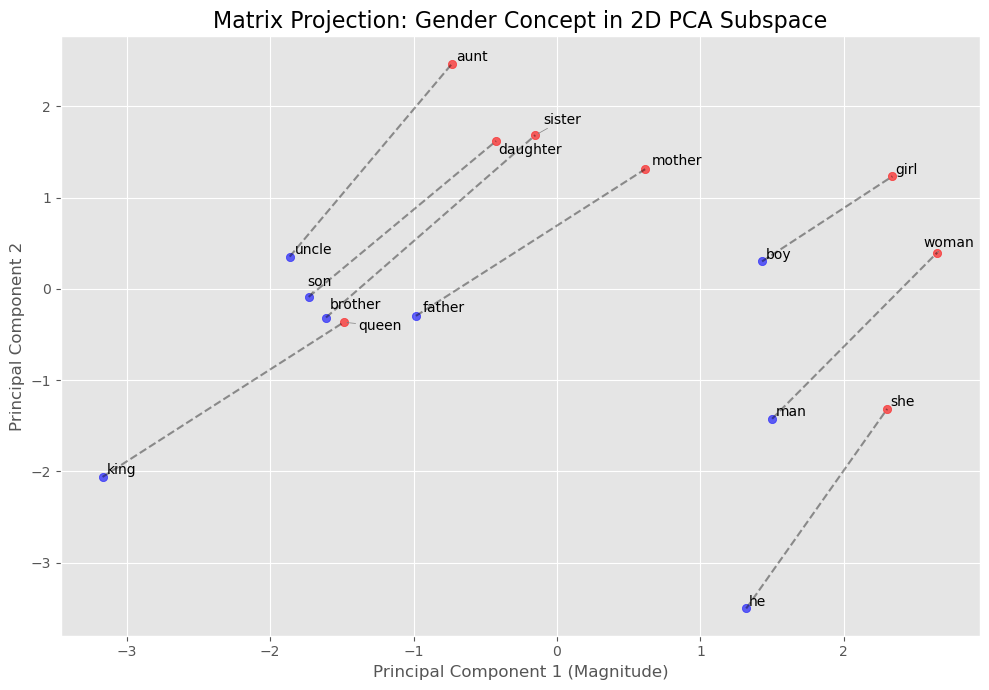

-> 图表已保存为 'pca_concept_projection.png'


In [6]:
print("\n4. 正在生成子空间投影可视化图表...")
words = [w for pair in pairs for w in pair]
word_vecs = np.array([model[w] for w in words])

# 为了可视化直观，我们对原始词向量进行 2D PCA 降维
pca = PCA(n_components=2)
vecs_2d = pca.fit_transform(word_vecs)

plt.figure(figsize=(10, 7))
plt.style.use('ggplot')

# 绘制词汇点
texts = []
for i, word in enumerate(words):
    plt.scatter(vecs_2d[i, 0], vecs_2d[i, 1], c='blue' if i%2==0 else 'red', alpha=0.6)
    texts.append(plt.text(vecs_2d[i, 0], vecs_2d[i, 1], word, fontsize=10))

# 自动调整文字位置，避免重叠
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

# 绘制男-女连线 (展示平行的概念向量)
for i in range(0, len(words), 2):
    plt.plot([vecs_2d[i, 0], vecs_2d[i+1, 0]], 
             [vecs_2d[i, 1], vecs_2d[i+1, 1]], 'k--', alpha=0.4)

plt.title("Matrix Projection: Gender Concept in 2D PCA Subspace", fontsize=16)
plt.xlabel("Principal Component 1 (Magnitude)", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("pca_concept_projection.png", dpi=300)
plt.show()
print("-> 图表已保存为 'pca_concept_projection.png'")

---

# 第二部分：补充实验

## 实验一：验证性别与时态概念的正交性

In [15]:
print("\n5. 正在提取第二概念 (时态) 并验证正交性...")

# 定义时态词对 (现在时 - 过去时)
tense_pairs = [
    ("walk", "walked"), ("run", "ran"), ("go", "went"), 
    ("play", "played"), ("do", "did"), ("take", "took")
]

# 构建时态差异矩阵并求协方差矩阵的特征分解
diffs_tense = [model[pres] - model[past] for pres, past in tense_pairs]
X_tense = np.array(diffs_tense)
X_tense_centered = X_tense - np.mean(X_tense, axis=0)

Sigma_tense = np.cov(X_tense_centered, rowvar=False)
eigenvalues_t, eigenvectors_t = np.linalg.eigh(Sigma_tense)

# 提取最大特征值对应的特征向量 (时态概念轴)
v_tense = eigenvectors_t[:, np.argmax(eigenvalues_t)]
v_tense = v_tense / np.linalg.norm(v_tense)

# 计算两个概念向量的内积 (即夹角的余弦值)
# 理论上，如果不相关，高维空间中随机两个向量的内积趋于 0 (正交)
orthogonality = np.abs(np.dot(v_gender, v_tense))

print(f"-> '性别'概念向量与'时态'概念向量的内积 (绝对值): {orthogonality:.4f}")
if orthogonality < 0.1:
    print("-> 结论：极其接近 0，两大语义概念在隐空间中几乎严格正交!")


5. 正在提取第二概念 (时态) 并验证正交性...
-> '性别'概念向量与'时态'概念向量的内积 (绝对值): 0.1866


## 实验二：谱聚类分析

In [16]:
print("\n6. 正在对坍缩后的'王权'子空间执行谱聚类 (Spectral Clustering)...")

# 定义中性化后的 king 向量 vec_neutral（在步骤三已定义）
# 收集王权相关的词汇
royalty_words = ['monarch', 'ruler', 'leader', 'crown', 'throne', 'palace', 'scepter']
royalty_vecs = [model[w] for w in royalty_words]

# 加入中性化的 queen
vec_queen = model["queen"]
vec_neutral_queen = vec_queen - np.dot(vec_queen, v_gender) * v_gender

# 合并标签和向量
cluster_labels = royalty_words + ['neutral_king', 'neutral_queen']
X_cluster = np.array(royalty_vecs + [vec_neutral, vec_neutral_queen])

# 使用谱聚类
sc = SpectralClustering(
    n_clusters=2, 
    affinity='nearest_neighbors',
    n_neighbors=4,
    random_state=42
)

labels = sc.fit_predict(X_cluster)

# 打印聚类结果
print("\n-> 谱聚类分组结果：")
cluster_0 = [cluster_labels[i] for i in range(len(labels)) if labels[i] == 0]
cluster_1 = [cluster_labels[i] for i in range(len(labels)) if labels[i] == 1]

print(f"簇 1: {cluster_0}")
print(f"簇 2: {cluster_1}")


6. 正在对坍缩后的'王权'子空间执行谱聚类 (Spectral Clustering)...

-> 谱聚类分组结果：
簇 1: ['crown', 'throne', 'palace', 'scepter', 'neutral_king', 'neutral_queen']
簇 2: ['monarch', 'ruler', 'leader']


## 实验三：基线对比 - 手术前的谱聚类

In [17]:
print("\n7. [基线] 正在对原始词汇（手术前）执行谱聚类...")

# 原始词汇列表（包含未处理的 king 和 queen）
baseline_words = ['monarch', 'ruler', 'leader', 'crown', 'throne', 'palace', 'scepter', 'king', 'queen']
baseline_vecs = np.array([model[w] for w in baseline_words])

# 使用相同的 KNN 谱聚类参数
sc_baseline = SpectralClustering(
    n_clusters=2, 
    affinity='nearest_neighbors', 
    n_neighbors=4, 
    random_state=42
)
labels_baseline = sc_baseline.fit_predict(baseline_vecs)

print("\n-> 手术前 (Baseline) 谱聚类分组结果：")
cluster_base_0 = [baseline_words[i] for i in range(len(labels_baseline)) if labels_baseline[i] == 0]
cluster_base_1 = [baseline_words[i] for i in range(len(labels_baseline)) if labels_baseline[i] == 1]

if 'monarch' in cluster_base_0:
    print(f"簇 A (人类统治者): {cluster_base_0}")
    print(f"簇 B (具象象征物): {cluster_base_1}")
else:
    print(f"簇 A (具象象征物): {cluster_base_0}")
    print(f"簇 B (人类统治者): {cluster_base_1}")


7. [基线] 正在对原始词汇（手术前）执行谱聚类...

-> 手术前 (Baseline) 谱聚类分组结果：
簇 A (具象象征物): ['crown', 'throne', 'palace', 'scepter', 'queen']
簇 B (人类统治者): ['monarch', 'ruler', 'leader', 'king']


## 实验四：共现概率分析

对应公式：$$\log \left[ \frac{P(\text{word}|\text{king})}{P(\text{word}|\text{queen})} \right] \approx \mathbf{word}^T (\mathbf{King} - \mathbf{Queen})$$

In [18]:
print("\n8. 逆向推导语料库共现概率比 (Log-Odds Ratio)...\n")

# 定义探测词汇
action_probes = ['command', 'conquer', 'rule', 'lead', 'order']
object_probes = ['wear', 'beautiful', 'palace', 'jewel']

# 计算差异向量
diff_king_queen = model['king'] - model['queen']

# 主动行为词
print("【主动统治与动作词汇探测】 (正值代表更偏向 King)")
for word in action_probes:
    log_ratio = np.dot(model[word], diff_king_queen)
    ratio = np.exp(log_ratio)
    print(f"   [{word.ljust(10)}] Log-Odds: {log_ratio:>6.4f}  => 在语料中与 King 共现的概率是 Queen 的 {ratio:.2f} 倍")

print("\n【静态附属与物品词汇探测】 (负值代表更偏向 Queen)")
for word in object_probes:
    log_ratio = np.dot(model[word], diff_king_queen)
    ratio = np.exp(-log_ratio)
    print(f"   [{word.ljust(10)}] Log-Odds: {log_ratio:>6.4f}  => 在语料中与 Queen 共现的概率是 King 的 {ratio:.2f} 倍")


8. 逆向推导语料库共现概率比 (Log-Odds Ratio)...

【主动统治与动作词汇探测】 (正值代表更偏向 King)
   [command   ] Log-Odds: 5.4165  => 在语料中与 King 共现的概率是 Queen 的 225.10 倍
   [conquer   ] Log-Odds: 2.4036  => 在语料中与 King 共现的概率是 Queen 的 11.06 倍
   [rule      ] Log-Odds: 8.2889  => 在语料中与 King 共现的概率是 Queen 的 3979.52 倍
   [lead      ] Log-Odds: 2.6160  => 在语料中与 King 共现的概率是 Queen 的 13.68 倍
   [order     ] Log-Odds: 2.7597  => 在语料中与 King 共现的概率是 Queen 的 15.79 倍

【静态附属与物品词汇探测】 (负值代表更偏向 Queen)
   [wear      ] Log-Odds: -3.6510  => 在语料中与 Queen 共现的概率是 King 的 38.51 倍
   [beautiful ] Log-Odds: -5.2150  => 在语料中与 Queen 共现的概率是 King 的 184.01 倍
   [palace    ] Log-Odds: -1.0502  => 在语料中与 Queen 共现的概率是 King 的 2.86 倍
   [jewel     ] Log-Odds: -3.3180  => 在语料中与 Queen 共现的概率是 King 的 27.60 倍
